# Predicting Prostate Cancer Grade from Whole-Slide Images: My Max-Pooling MIL Baseline

**Context**: I built this notebook as my introduction to computational pathology. I came to this field from computer vision, so I wanted to learn how whole-slide images work and get comfortable with Multiple Instance Learning (MIL), the idea behind most pathology AI. The problem MIL solves is predicting one label for a whole biopsy slide when there are no labels for the thousands of small patches inside it. I use the PANDA Challenge dataset (prostate cancer biopsies from two hospitals) as a public testbed for that problem.

**The model**: a simple max-pooling MIL model. It splits each slide into patches, scores every patch on its own, and uses the single highest patch score as the prediction for the whole slide. The label is whether the slide shows clinically significant cancer (ISUP grade 2 or higher). I evaluate it with 5-fold cross-validation, a 95% confidence interval, and a test across the two hospitals.

## How I built this notebook

**My part:** I chose the problem, the dataset and the design: a max-pooling MIL model, a balanced set of slides from both hospitals, random tiles, a clinical label cutoff, and cross-validation with a cross-hospital test. I ran every cell and wrote the interpretation sections.

**AI-assisted part:** most of the code was written with Claude (Anthropic's AI assistant). I went through each part so I can explain what it does and why.

---
## Setup

In [ ]:
!pip install -q openslide-python openslide-bin

In [2]:
import os, glob, zlib, random, time

import numpy as np
import pandas as pd
import openslide
from PIL import Image

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Two colors for every plot: blue = ISUP 0 to 1 (label 0), orange = ISUP 2 or higher (label 1)
C_LOW, C_HIGH, C_GRAY = '#2a78d6', '#eb6834', '#8a8a8a'

def set_seed(seed):
    # Same seed, same numbers: makes every run repeatable
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

Using device: cuda


In [3]:
# ---------------- Config: every setting in one place ----------------
PANDA_DIR = '/kaggle/input/competitions/prostate-cancer-grade-assessment'
LABELS_CSV = os.path.join(PANDA_DIR, 'train.csv')
SLIDE_DIR = os.path.join(PANDA_DIR, 'train_images')
assert os.path.exists(LABELS_CSV), 'Add the competition "Prostate cANcer graDe Assessment" with Add Input'

WORK = '/kaggle/working'
CACHE_DIR = f'{WORK}/cache_baseline'
os.makedirs(CACHE_DIR, exist_ok=True)

GRADE_CUTOFF = 2      # ISUP grade >= 2 counts as "clinically significant" (label 1)
N_SLIDES = 300        # sampled evenly across label and hospital
SUBSET_SEED = 0

TILE = 256            # tile size in pixels
LEVEL = 1             # PANDA pyramid level 1 = 4x downsampled from full resolution
MAX_TILES = 200       # tiles sampled per slide
MIN_TISSUE = 0.25     # a tile must be at least 25% tissue (biopsies are thin strips)

N_FOLDS = 5
SEED = 0              # fixes all randomness, so every run gives the same numbers
EPOCHS = 20
LR = 1e-4

---
# Part 0: Data Exploration

Before writing any model code, I want to look at what I'm working with: how the grades are distributed, where the slides come from, and what the images look like.

**A quick primer on the labels.** Pathologists grade prostate cancer by the patterns of the glands. The **ISUP grade group** runs from 0 (no cancer) to 5 (most aggressive). Grade group 1 is usually low-risk and often just monitored, while **grade group 2 and above** is considered clinically significant and usually treated. That's why I use ISUP 2 or higher as my positive label.

**Two hospitals.** PANDA slides come from two centers, **Karolinska** (Sweden) and **Radboud** (Netherlands). They use different scanners and staining, so the same tissue can look different in color. I sample slides evenly from both, and I use this later to test whether my model works across hospitals.

Slides in PANDA: 10616
isup_grade        0     1     2     3     4     5    All
data_provider                                           
karolinska     1925  1814   668   317   481   251   5456
radboud         967   852   675   925   768   973   5160
All            2892  2666  1343  1242  1249  1224  10616


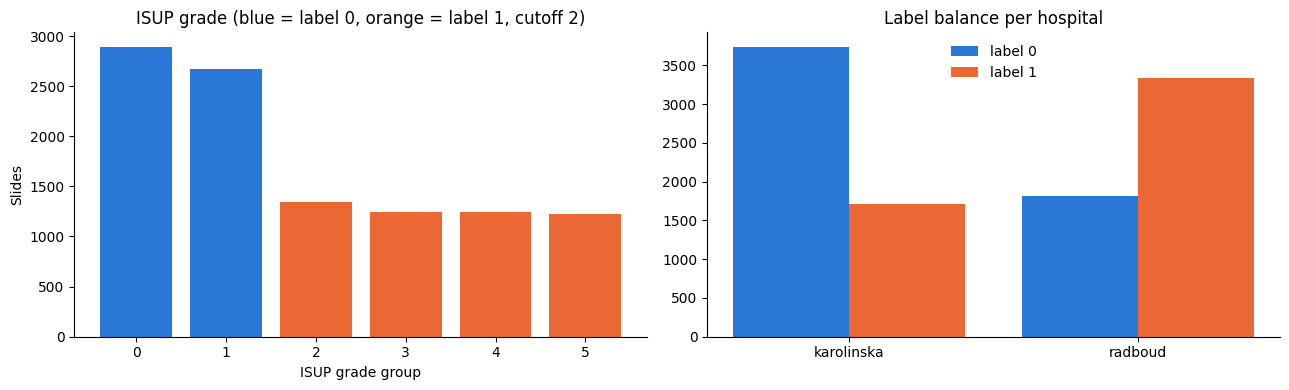

In [4]:
labels_all = pd.read_csv(LABELS_CSV)
labels_all['label'] = (labels_all['isup_grade'] >= GRADE_CUTOFF).astype(int)
print('Slides in PANDA:', len(labels_all))
print(pd.crosstab(labels_all['data_provider'], labels_all['isup_grade'], margins=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
g = labels_all['isup_grade'].value_counts().sort_index()
axes[0].bar(g.index.astype(str), g.values, color=[C_LOW if i < GRADE_CUTOFF else C_HIGH for i in g.index])
axes[0].set_title(f'ISUP grade (blue = label 0, orange = label 1, cutoff {GRADE_CUTOFF})')
axes[0].set_xlabel('ISUP grade group'); axes[0].set_ylabel('Slides')

ct = pd.crosstab(labels_all['data_provider'], labels_all['label'])
x = np.arange(len(ct))
axes[1].bar(x - 0.2, ct[0], 0.4, color=C_LOW, label='label 0')
axes[1].bar(x + 0.2, ct[1], 0.4, color=C_HIGH, label='label 1')
axes[1].set_xticks(x); axes[1].set_xticklabels(ct.index)
axes[1].set_title('Label balance per hospital'); axes[1].legend(frameon=False)
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [5]:
# Balanced subset: equal numbers from each (hospital, label) group
per_group = N_SLIDES // 4
subset_df = pd.concat([d.sample(min(per_group, len(d)), random_state=SUBSET_SEED)
                       for _, d in labels_all.groupby(['data_provider', 'label'])])
subset_df = subset_df[subset_df['image_id'].apply(lambda s: os.path.exists(os.path.join(SLIDE_DIR, f'{s}.tiff')))]
subset_df = subset_df.reset_index(drop=True)
print(f'Subset: {len(subset_df)} slides')
print(pd.crosstab(subset_df['data_provider'], subset_df['label']))

Subset: 300 slides
label           0   1
data_provider        
karolinska     75  75
radboud        75  75


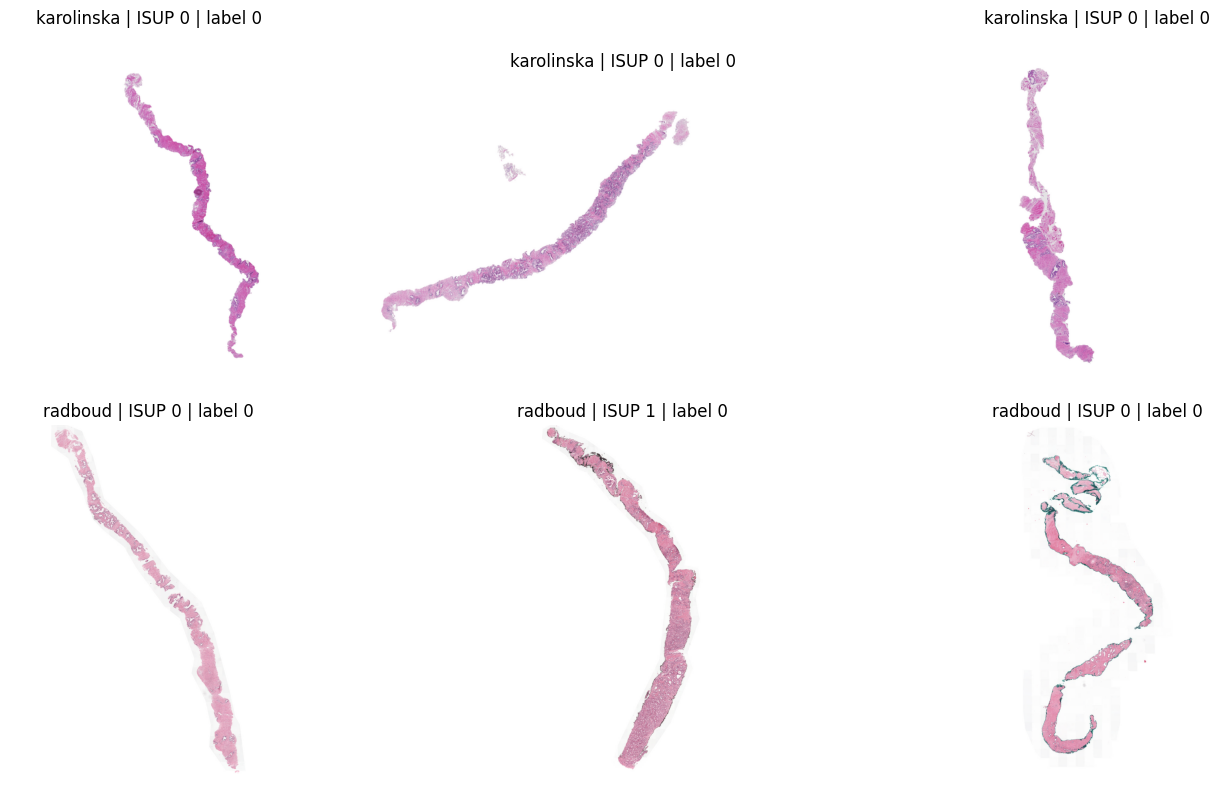

In [6]:
# A few whole-slide thumbnails from each hospital. Slides are far too large to load
# at full resolution just to look at, so OpenSlide makes a low-resolution preview.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for r, provider in enumerate(['karolinska', 'radboud']):
    rows = subset_df[subset_df['data_provider'] == provider].head(3)
    for ax, (_, row) in zip(axes[r], rows.iterrows()):
        slide = openslide.OpenSlide(os.path.join(SLIDE_DIR, f"{row['image_id']}.tiff"))
        ax.imshow(slide.get_thumbnail((800, 800)))
        ax.set_title(f"{provider} | ISUP {row['isup_grade']} | label {row['label']}")
        slide.close()
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

**What I noticed:** even at thumbnail resolution, the amount of tissue versus blank background varies a lot from slide to slide, and the tissue is a tiny fraction of the full image. That convinced me I need a tissue-detection step before tiling, otherwise most of my patches (and compute) would go to blank glass.

Looking at the thumbnails, the two hospitals' slides also look different from each other: the Karolinska slides are a deeper purple-pink, the Radboud slides are lighter and pinker, and some Radboud slides have marker pen lines on them. A model could pick up on differences like these instead of the cancer, which is why I test across hospitals in Part 3.

---
# Part 1: My Approach, Simple MIL with Max-Pooling

**My reasoning for this design:** I only have one label per slide, not per patch, so I can't train a normal per-patch classifier directly. The simplest way to bridge this gap, before reaching for anything like learned attention, is:

1. Score every patch independently with a small classifier (does THIS patch look positive?).
2. Combine those per-patch scores into one slide-level score using a fixed rule, not a learned one.

For the combination rule, I chose **max-pooling**: the slide's prediction is the single highest patch score. The classic MIL assumption is that a bag is positive if *at least one* instance in it is positive. Max-pooling implements that directly: if any one patch looks strongly positive, the whole slide is predicted positive. For cancer grading this also fits how the label works, since a slide's grade is driven by its most aggressive areas.

## Step 1: Tissue Detection

Most of a slide is empty glass, and I only want patches of tissue. On these slides the glass is almost pure white, while stained tissue is darker. So I make a small **grayscale** version of each slide, where every pixel is one brightness number from 0 (black) to 255 (white), and mark every pixel darker than 220 as tissue. That gives me a yes/no map of the slide, called a **tissue mask**.

Later, to decide whether a square is worth keeping, I just look up that square on the mask and count how much of it is "yes". This is much faster than opening each square of the real image to check it.

In [7]:
GRAY_CUTOFF = 220   # pixels brighter than this (out of 255) count as empty glass
MASK_DS = 16        # the mask is 16 times smaller than the full slide

def tissue_mask(slide):
    # A small grayscale picture of the slide: glass is near-white, tissue is darker
    W, H = slide.dimensions
    thumb = slide.get_thumbnail((W // MASK_DS, H // MASK_DS)).convert('RGB')
    gray = np.array(thumb.convert('L'))       # one brightness number per pixel
    mask = gray < GRAY_CUTOFF                 # True = darker than glass = tissue
    scale = (W / gray.shape[1], H / gray.shape[0])   # full-size pixels per mask pixel
    return mask, np.array(thumb), scale

def tissue_fraction(mask, scale, x0, y0, size0):
    # What share of a square (given in full-size pixels) is tissue, looked up on the mask
    sx, sy = scale
    top, bottom = int(y0 / sy), int((y0 + size0) / sy)
    left, right = int(x0 / sx), int((x0 + size0) / sx)
    patch = mask[top:bottom, left:right]
    if patch.size == 0:
        return 0.0
    return float(patch.mean())

## Step 2: Tiling a Whole-Slide Image

A whole-slide image is too large to process at once, so I split it into a grid of 256 x 256 patches, keep the ones that are mostly tissue, and **sample up to 200 of them at random from the whole tissue area** (small biopsies have fewer, so the median is 39 per slide). If I simply kept the first 200 tiles while scanning from the top, the bottom of every slide would never be seen. Random sampling gives every part of the tissue an equal chance.

I read from pyramid level 1 (4 times smaller than full resolution) to keep this fast. That is enough to see gland patterns, which is what grading is based on.

In [8]:
def tile_coords(slide, mask, scale, rng, level=LEVEL, tile=TILE, max_tiles=MAX_TILES):
    # Returns up to max_tiles (x, y) positions in full-resolution coordinates, sampled from all tissue
    level = min(level, slide.level_count - 1)
    ds = slide.level_downsamples[level]
    size0 = int(round(tile * ds))              # one tile's size in full-resolution pixels
    W, H = slide.dimensions
    coords = [(x, y) for y in range(0, H - size0 + 1, size0) for x in range(0, W - size0 + 1, size0)
              if tissue_fraction(mask, scale, x, y, size0) >= MIN_TISSUE]
    if len(coords) > max_tiles:
        coords = [coords[i] for i in np.sort(rng.choice(len(coords), max_tiles, replace=False))]
    return coords, level, size0

def read_tiles(slide, coords, level, tile=TILE):
    # read_region always takes full-resolution (level 0) coordinates
    return [np.array(slide.read_region((int(x), int(y)), level, (tile, tile)).convert('RGB')) for x, y in coords]

67 tissue tiles sampled


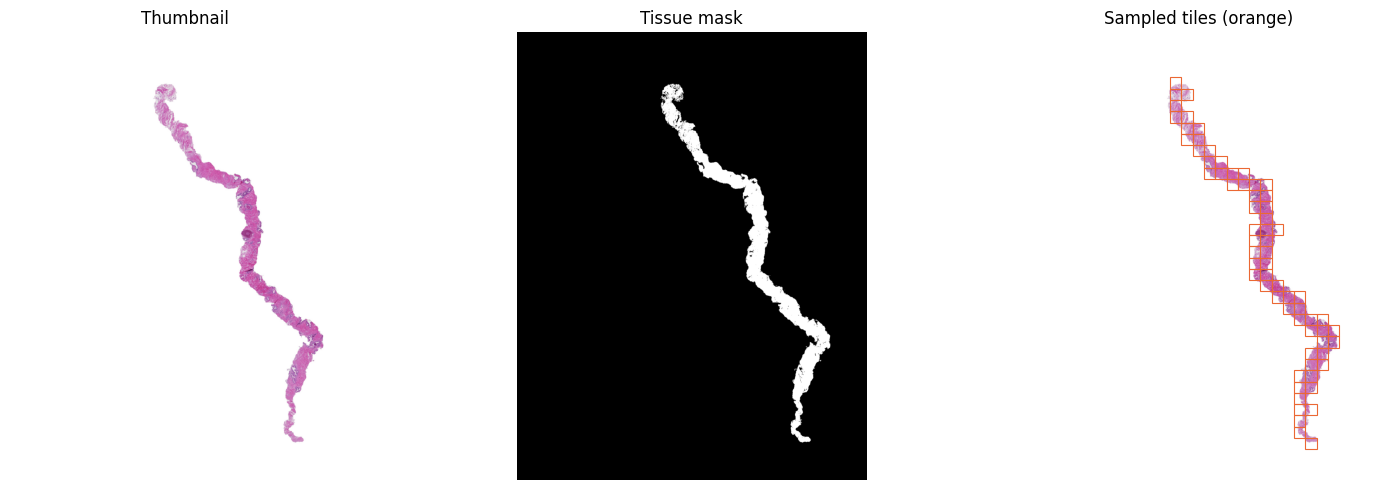

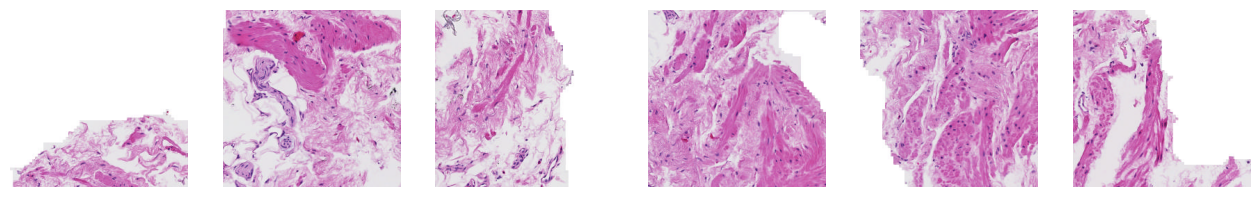

In [9]:
# Sanity check on one real slide: the mask should cover the tissue, and the tiles should look like tissue
example_id = subset_df.iloc[0]['image_id']
slide = openslide.OpenSlide(os.path.join(SLIDE_DIR, f'{example_id}.tiff'))
mask, thumb, scale = tissue_mask(slide)
coords, level, size0 = tile_coords(slide, mask, scale, np.random.default_rng(0))
print(f'{len(coords)} tissue tiles sampled')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(thumb); axes[0].set_title('Thumbnail')
axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Tissue mask')
axes[2].imshow(thumb); axes[2].set_title('Sampled tiles (orange)')
sx, sy = scale
for (x, y) in coords:
    axes[2].add_patch(mpatches.Rectangle((x / sx, y / sy), size0 / sx, size0 / sy, fill=False, ec=C_HIGH, lw=0.8))
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for ax, t in zip(axes, read_tiles(slide, coords[:6], level)):
    ax.imshow(t); ax.axis('off')
plt.show()
slide.close()

**What I see:** the tiles are spread across the whole biopsy, not just one end of it, and the mask follows the tissue well. Some tiles sit at the edge of the tissue and are partly blank, because I keep any square that is at least a quarter tissue.

## Step 3: Patch Embeddings

A raw 256x256x3 patch is too large and unstructured to feed directly into a small classifier, so I compress each patch into a compact feature vector with a pretrained image encoder. I use a ResNet-18 pretrained on ImageNet. It isn't pathology-specific, but it's a fast, reasonable starting point that captures general visual structure (edges, textures, shapes). I keep it here on purpose, so this stays a simple baseline. In my lung notebook I switch to a pathology-pretrained encoder.

In [10]:
encoder = models.resnet18(weights='IMAGENET1K_V1')
encoder.fc = nn.Identity()  # strip the classification head so this outputs a 512-number feature vector
encoder.eval().to(device)

preprocess = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def embed_patches(patch_list, batch_size=64):
    out = []
    for i in range(0, len(patch_list), batch_size):
        tensors = torch.stack([preprocess(p) for p in patch_list[i:i + batch_size]]).to(device)
        out.append(encoder(tensors).cpu())
    return torch.cat(out, dim=0)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s] 


## Step 4: Building Bags and Caching Embeddings

I cache each slide's embeddings to disk after computing them once, since the encoder never changes during training, only the small classifier on top does. I also save each tile's coordinates, so I can go back and look at the exact patch that drove a prediction. The random tile sample is seeded from the slide's ID, so re-running always picks the same tiles.

In [11]:
for _, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc='Slides'):
    cache_path = os.path.join(CACHE_DIR, f"{row['image_id']}.pt")
    if os.path.exists(cache_path):
        continue
    try:
        slide = openslide.OpenSlide(os.path.join(SLIDE_DIR, f"{row['image_id']}.tiff"))
        mask, _, scale = tissue_mask(slide)
        rng = np.random.default_rng(zlib.crc32(row['image_id'].encode()))
        coords, level, size0 = tile_coords(slide, mask, scale, rng)
        if coords:
            torch.save({'emb': embed_patches(read_tiles(slide, coords, level)),
                        'coords': torch.tensor(coords), 'level': level}, cache_path)
        slide.close()
    except Exception as e:
        print(f"Skipping {row['image_id']}: {e}")

cache = {}
for sid in subset_df['image_id']:
    p = os.path.join(CACHE_DIR, f'{sid}.pt')
    if os.path.exists(p):
        cache[sid] = torch.load(p)
data = subset_df[subset_df['image_id'].isin(cache)].reset_index(drop=True)
print(f"Cached slides: {len(data)} | label 1: {data['label'].sum()} | tiles per slide: "
      f"median {int(np.median([len(cache[s]['emb']) for s in data.image_id]))}")

Slides:   0%|          | 0/300 [00:00<?, ?it/s]

Cached slides: 300 | label 1: 150 | tiles per slide: median 39


## Step 5:Simple MIL Model, Max-Pooling Over Per-Patch Scores

This is the core of my approach. Instead of pooling *features* and then classifying, I classify *each patch first*, then pool the resulting scores.

**Why I designed it this way:** it mirrors the classic MIL assumption in the simplest way I could think of: "score every patch on its own, and let the single most suspicious patch decide the slide's label." There's no learned weighting of patches, which makes it easy to reason about: the decision for the whole slide always traces back to exactly one patch.


In [12]:
class SimpleMaxPoolMIL(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=64):
        super().__init__()
        # a small classifier applied independently to every patch embedding
        self.instance_classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, bag):
        # bag: (num_patches, input_dim), all patch embeddings for one slide
        instance_logits = self.instance_classifier(bag).squeeze(-1)  # (num_patches,)
        bag_logit = instance_logits.max()                            # the most suspicious patch decides
        return bag_logit, instance_logits

# Shape check before training
m = SimpleMaxPoolMIL().to(device)
logit, inst = m(cache[data.image_id[0]]['emb'].to(device))
print('bag logit shape (expect scalar):', tuple(logit.shape), '| instance logits:', tuple(inst.shape))

bag logit shape (expect scalar): () | instance logits: (67,)


---
# Part 2: Evaluating My Model

To get a score I can trust, every slide must be judged by a model that never saw it during training. I use **5-fold cross-validation**:

1. Split the slides into 5 equal groups (folds), each with the same mix of positive and negative slides.
2. Train a model on 4 folds, and use it to predict the 5th fold, which it has never seen.
3. Repeat 5 times, so each fold gets predicted once.

At the end, every slide has exactly one honest prediction, and I compute **one AUROC over all slides**. The number of epochs (20) is fixed in advance, so I never pick the "best" epoch by looking at the results.

I also compute a **95% confidence interval** for the AUROC. It shows how much the number could move just by chance, given how many slides I have.

In [16]:
def train_model(train_ids, train_labels):
    set_seed(SEED)
    gen = torch.Generator().manual_seed(SEED)
    model = SimpleMaxPoolMIL().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    n_pos = max(int(train_labels.sum()), 1)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor((len(train_labels) - n_pos) / n_pos, device=device))
    for epoch in range(EPOCHS):
        model.train()
        for i in torch.randperm(len(train_ids), generator=gen).tolist():
            logit, _ = model(cache[train_ids[i]]['emb'].to(device))
            loss = criterion(logit, torch.tensor(float(train_labels[i]), device=device))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model

@torch.no_grad()
def predict(model, ids):
    model.eval()
    return np.array([torch.sigmoid(model(cache[s]['emb'].to(device))[0]).item() for s in ids])

def bootstrap_auroc(y_true, y_prob, n=2000):
    # Re-draw the slides with replacement 2000 times and recompute the AUROC each time
    rng = np.random.default_rng(SEED)
    scores = []
    for _ in range(n):
        idx = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) == 2:
            scores.append(roc_auc_score(y_true[idx], y_prob[idx]))
    return np.percentile(scores, [2.5, 97.5])

In [17]:
ids = data['image_id'].values
y = data['label'].values.astype(int)

oof = np.zeros(len(ids))                 # one held-out prediction per slide
fold_of = np.zeros(len(ids), dtype=int)  # which fold each slide was held out in
fold_models = {}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
for k, (train_idx, test_idx) in enumerate(skf.split(ids, y)):
    model = train_model(ids[train_idx], y[train_idx])
    oof[test_idx] = predict(model, ids[test_idx])
    fold_of[test_idx] = k
    fold_models[k] = model
    print(f'Fold {k + 1}: trained on {len(train_idx)} slides, predicted {len(test_idx)}')

auroc = roc_auc_score(y, oof)
lo, hi = bootstrap_auroc(y, oof)
print(f'\nOut-of-fold AUROC: {auroc:.3f}  (95% confidence interval: {lo:.3f} to {hi:.3f})')

Fold 1: trained on 240 slides, predicted 60
Fold 2: trained on 240 slides, predicted 60
Fold 3: trained on 240 slides, predicted 60
Fold 4: trained on 240 slides, predicted 60
Fold 5: trained on 240 slides, predicted 60

Out-of-fold AUROC: 0.786  (95% confidence interval: 0.733 to 0.834)


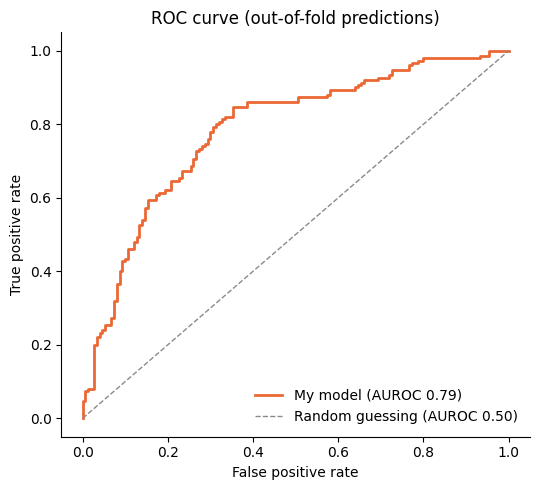

In [15]:
fpr, tpr, _ = roc_curve(y, oof)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color=C_HIGH, lw=2, label=f'My model (AUROC {auroc:.2f})')
ax.plot([0, 1], [0, 1], color=C_GRAY, lw=1, ls='--', label='Random guessing (AUROC 0.50)')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC curve (out-of-fold predictions)')
ax.legend(frameon=False, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**What the numbers mean:** My max-pooling model reached an out-of-fold AUROC of 0.79 (95% confidence interval 0.73 to 0.83), so if I pick one clinically significant slide and one that isn't, it ranks the significant one higher about 79% of the time, and the whole interval is well above 0.5. The ROC curve rises steeply at first, catching about 62% of significant slides while wrongly flagging only 20% of the others, but then flattens around 85%, which means some cancer slides get low scores. My guess is that these are slides where the cancer area is small and none of the sampled tiles show it, since only the single top patch decides.

---
# Part 3: Does It Work at Another Hospital?

Cross-validation mixes both hospitals in training and testing. A harder, more realistic test is to **train only on one hospital's slides and test on the other's**. A clinical tool will always meet slides from scanners and labs it never saw.

If the AUROC drops a lot compared with cross-validation, the model partly learned hospital-specific things (like stain color) instead of the cancer itself. This is called **domain shift**.

In [18]:
cross = []
for train_site, test_site in [('karolinska', 'radboud'), ('radboud', 'karolinska')]:
    tr = data['data_provider'].values == train_site
    te = data['data_provider'].values == test_site
    model = train_model(ids[tr], y[tr])
    cross.append({'train on': train_site, 'test on': test_site,
                  'AUROC': roc_auc_score(y[te], predict(model, ids[te]))})
print(pd.DataFrame(cross).round(3).to_string(index=False))
print(f'\nFor comparison, mixed cross-validation: {auroc:.3f}')

  train on    test on  AUROC
karolinska    radboud  0.722
   radboud karolinska  0.634

For comparison, mixed cross-validation: 0.786


**What the cross-hospital test shows:** Trained on Karolinska and tested on Radboud, my model reached an AUROC of 0.722, and in the other direction 0.634, both lower than the 0.786 from mixed cross-validation. This suggests the model partly learned patterns specific to the hospital it trained on, so it doesn't fully carry over to slides from a new hospital (domain shift). Part of the drop may also come from training on only 150 slides from one hospital instead of 240, and each direction is a single run, so I treat the exact gap as rough.

---
# Part 4: Looking at the Patch That "Won"

Since my model's decision always traces back to one max-scoring patch, I can look at that exact patch. This is a simple form of interpretability that comes free with this design. I use the model from the fold where the slide was **held out**, so it never trained on it, and I show the top-scoring and lowest-scoring patches next to each other.

Slide b25d89f0b0cfe730c74db9e616b95522 | ISUP 4 | predicted p = 0.98


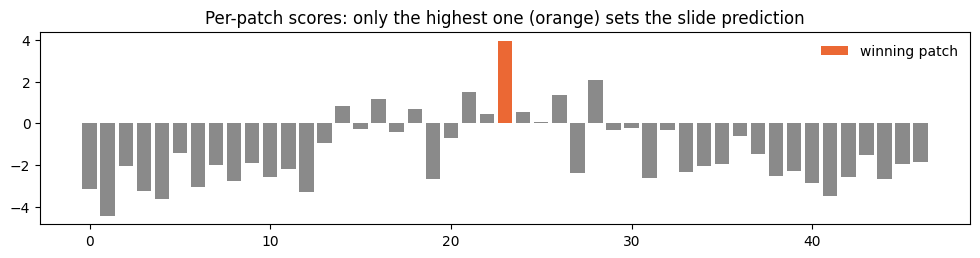

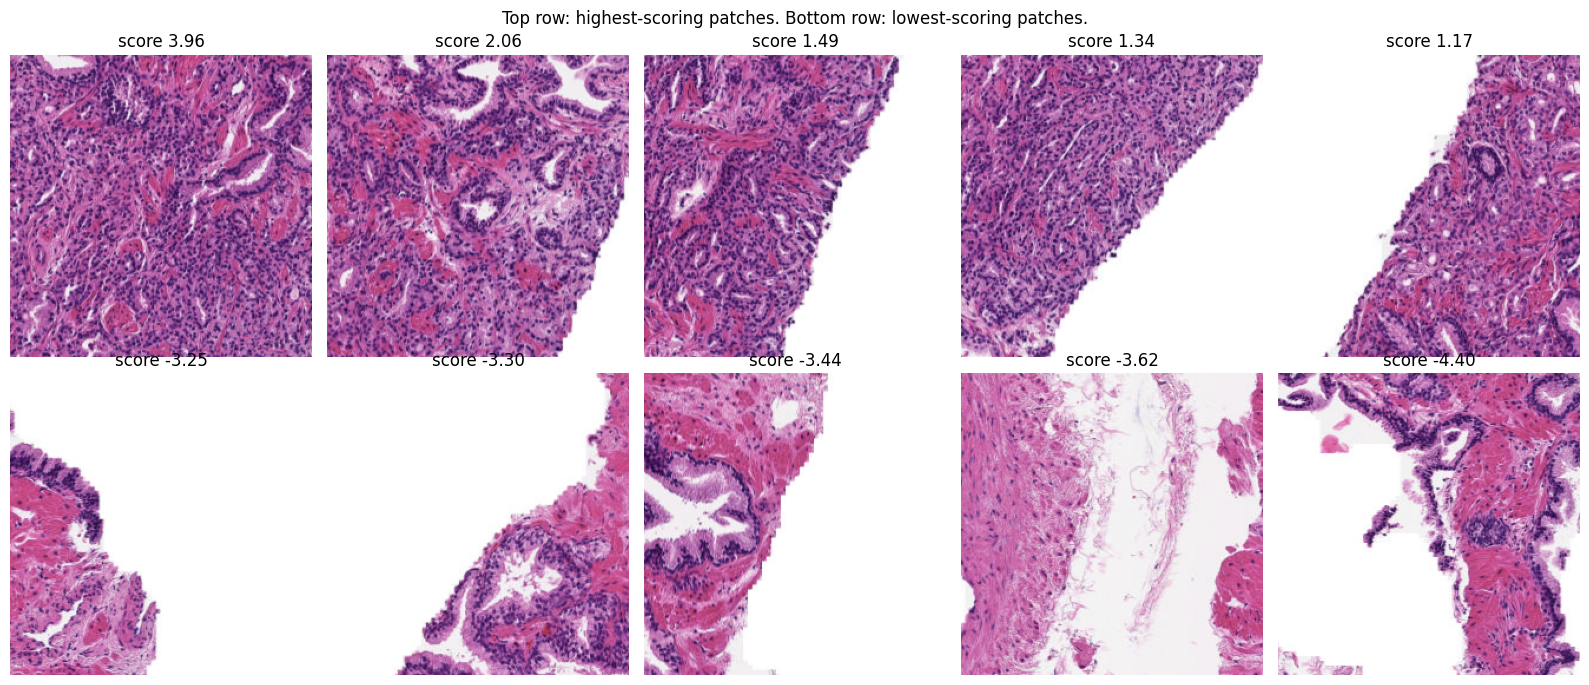

In [19]:
pos_idx = np.where(y == 1)[0]
i = pos_idx[np.argmax(oof[pos_idx])]          # the clinically significant slide the model scored highest
sid = ids[i]
model = fold_models[fold_of[i]].eval()

with torch.no_grad():
    logit, inst = model(cache[sid]['emb'].to(device))
inst = inst.cpu().numpy()
order = np.argsort(-inst)
print(f"Slide {sid} | ISUP {data.loc[i, 'isup_grade']} | predicted p = {oof[i]:.2f}")

plt.figure(figsize=(12, 2.5))
plt.bar(range(len(inst)), inst, color=C_GRAY)
plt.bar([order[0]], [inst[order[0]]], color=C_HIGH, label='winning patch')
plt.title('Per-patch scores: only the highest one (orange) sets the slide prediction')
plt.legend(frameon=False)
plt.show()

slide = openslide.OpenSlide(os.path.join(SLIDE_DIR, f'{sid}.tiff'))
coords = [tuple(c) for c in cache[sid]['coords'].tolist()]
n_show = max(1, min(5, len(order) // 2))       # never show the same patch in both rows
fig, axes = plt.subplots(2, n_show, figsize=(3.2 * n_show, 7), squeeze=False)
for ax, k in zip(axes[0], order[:n_show]):
    ax.imshow(read_tiles(slide, [coords[k]], cache[sid]['level'])[0]); ax.set_title(f'score {inst[k]:.2f}'); ax.axis('off')
for ax, k in zip(axes[1], order[-n_show:]):
    ax.imshow(read_tiles(slide, [coords[k]], cache[sid]['level'])[0]); ax.set_title(f'score {inst[k]:.2f}'); ax.axis('off')
plt.suptitle('Top row: highest-scoring patches. Bottom row: lowest-scoring patches.')
plt.tight_layout()
plt.show()
slide.close()

**What the winning patches look like:** the top-scoring patches are packed with many small glands and dark nuclei, while the lowest-scoring ones show larger, open glands, pink muscle-like tissue, or mostly blank space at the tissue edge. That fits what I read about prostate cancer grading: higher grades have smaller, more crowded and less organized glands. I'm not a pathologist, so I treat this as a sanity check rather than proof.

---
## Summary

I built a max-pooling MIL baseline that predicts clinically significant prostate cancer (ISUP grade 2 or higher) from 300 PANDA whole-slide images, using up to 200 random tissue tiles per slide. Under 5-fold cross-validation it reached an AUROC of 0.79 (95% confidence interval 0.73 to 0.83), so it clearly learned something real from the tiles. When trained on one hospital and tested on the other, the AUROC dropped to 0.72 and 0.63, which showed me that a model can work well on familiar data and still struggle on a new hospital. This notebook taught me how MIL works on whole-slide images, and it is the baseline I build on in my lung notebook.

## Honest Limitations

- **ImageNet encoder.** The features come from everyday photos, not histology. A pathology-pretrained encoder should help, which I use in my lung notebook.
- **One patch decides.** Only the top-scoring patch gets a training signal on each slide, so most patches never directly shape the model.
- **Simple tissue detection.** A fixed brightness cutoff can count pen marks or dark dust as tissue.
- **Sampled tiles at one zoom level.** Up to 200 tiles (median 39) at pyramid level 1 per slide, so small cancer areas can be missed.
- **Binary label.** I simplified the 6-level ISUP scale to "grade 2 or higher," which throws away detail.


**One limitation I noticed myself:** many of the lowest-scoring patches sit at the edge of the tissue and are mostly blank. So the model may partly be scoring how much tissue a patch contains, not only what the tissue looks like.

## What's Next

In my next notebook I move to lung cancer and a harder, genomic label: predicting EGFR driver mutations from H&E slides. There I switch to a pathology-pretrained encoder and CLAM-style attention, which fixes the "one patch decides" limitation of this baseline.

